# Supporting 3 - ML methods and studies in detail

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

Reads what `scripts/run_pipeline.py` wrote. Every split is grouped by reservoir realisation; the test reservoirs were used once, at the end.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
df = pd.read_csv(Path(cfg.paths.data)/'scenarios_features.csv')
print(len(df), 'scenarios,', df.realisation_id.nunique(), 'realisations')
print('rows per partition:', S['ml']['leakage']['rows'], '| overlaps:', S['ml']['leakage']['overlaps'])
print(json.dumps(S['data_quality'], indent=1))

300 scenarios, 100 realisations
rows per partition: {'train': 168, 'calib': 57, 'test': 75} | overlaps: {'train_calib': 0, 'train_test': 0, 'calib_test': 0}
{
 "n_rows": 300,
 "n_failed_runs": 0,
 "duplicate_scenario_ids": 0,
 "duplicate_input_rows": 0,
 "missing_values_total": 0,
 "constant_columns_dropped_from_analysis": [
  "n_layers",
  "mass_lost_kg",
  "sg_min",
  "n_clipped",
  "max_clip",
  "max_bhp_spread_Pa",
  "sg_threshold",
  "p_limit_Pa",
  "mass_lost_Mt"
 ],
 "scenarios_with_a_rate_on_the_floor_or_ceiling": 0,
 "checks": {
  "saturation_in_bounds": true,
  "mass_balance_below_1e-9": true,
  "no_clipping": true,
  "positive_buildup": true,
  "common_bhp_below_1Pa": true
 },
 "duplicate_rows_dropped": 0
}


## Model comparison (course families) and held-out errors in physical units

In [2]:
rows = []
for t, r in S['ml']['targets'].items():
    rows.append({'target': t, 'unit': r['unit'], 'selected': r['selected_model'],
                 'test MAE': r['test']['MAE'], 'test RMSE': r['test']['RMSE'], 'test R2': r['test']['R2'],
                 'max error': r['test']['max_error'], 'mean-baseline RMSE': r['mean_baseline_test']['RMSE'],
                 'band coverage (measured)': r['error_band']['measured_coverage_test']})
display(pd.DataFrame(rows))
display(pd.DataFrame({t: r['model_comparison_test_rmse_physical_units'] for t, r in S['ml']['targets'].items()}))

,target,unit,selected,test MAE,test RMSE,test R2,max error,mean-baseline RMSE,band coverage (measured)
0,dp_bh_max_MPa,MPa,lasso,0.409308,0.825779,0.970204,3.594852,4.814258,0.946667
1,r_plume_m95_m,m,linear,5.205678,7.637725,0.997078,30.314641,142.267391,0.920000
2,sweep_efficiency,-,elasticnet,0.001376,0.001951,0.969508,0.008886,0.011221,0.893333


,dp_bh_max_MPa,r_plume_m95_m,sweep_efficiency
mean,5.045558,143.325361,0.011221
linear,0.821952,7.637725,0.001984
ridge,0.812697,8.758103,0.002120
lasso,0.825779,9.910519,0.002646
elasticnet,0.816946,7.573195,0.001951
knn,2.126388,58.394386,0.004935
svr,0.932353,15.213871,0.002814
tree,0.873471,17.398611,0.002759
random_forest,0.819342,14.523351,0.002705
gradient_boosting,0.773412,11.452938,0.002213


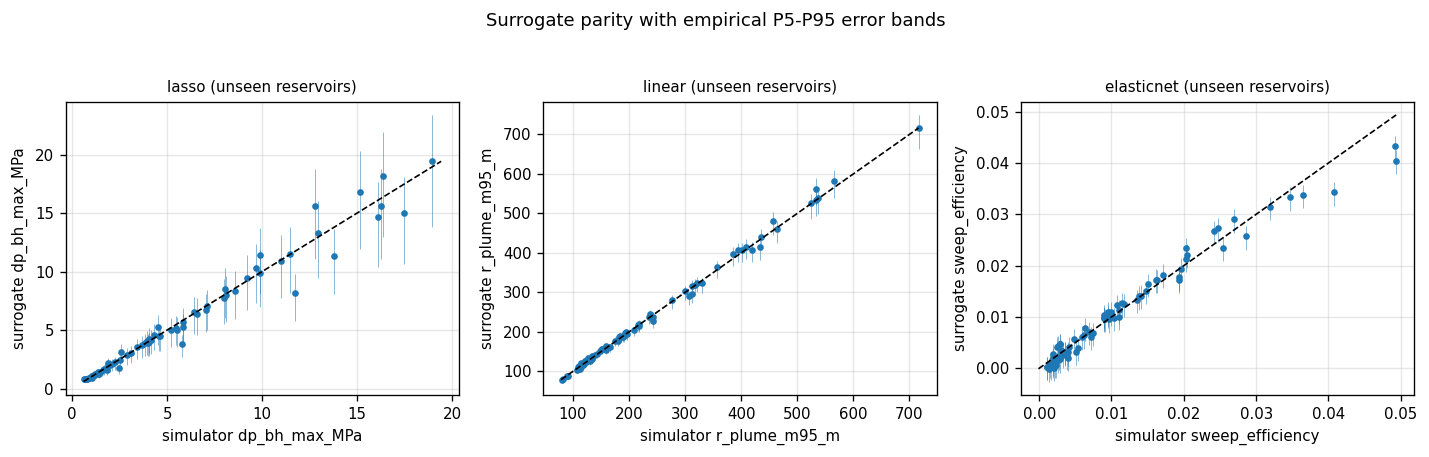

In [3]:
display(Image(str(Path(cfg.paths.figures)/'06_surrogate_parity.png')))

## Where the surrogates fail

In [4]:
for t, r in S['ml']['targets'].items():
    h = r['difficult_cases']
    print(f"\n{t}: worst 10% of test cases carry {100*h['share_of_total_abs_error_from_worst_10pct']:.0f}% of the absolute error")
    display(pd.DataFrame(h['worst_cases']).round(3))
    display(pd.DataFrame(h['by_permeability_tercile']))
    display(pd.DataFrame(h['by_schedule_intensity_tercile']))


dp_bh_max_MPa: worst 10% of test cases carry 54% of the absolute error


,scenario_id,dp_bh_max_MPa,pred,abs_err,rel_err,k_median_mD,V_DP,h_total_m,r_e_m,q_mult_mean,r_fill_over_re
0,R0036_S+02,11.751,8.156,3.595,0.306,40.497,0.708,32.293,2507.616,1.757,0.075
1,R0016_S+02,12.796,15.602,2.806,0.219,86.633,0.302,60.725,3913.995,3.488,0.101
2,R0005_S+00,13.805,11.362,2.443,0.177,134.112,0.294,55.676,3920.709,2.357,0.105
3,R0093_S+00,17.458,15.021,2.437,0.140,345.941,0.834,69.891,2696.284,3.210,0.130
4,R0036_S+01,5.762,3.810,1.953,0.339,40.497,0.708,32.293,2507.616,0.851,0.052


,k_bin,n,MAE,median_rel_err
0,low k,27,0.776192,0.082383
1,mid k,24,0.291621,0.030135
2,high k,24,0.114251,0.015487


,q_bin,n,MAE,median_rel_err
0,gentle,25,0.080084,0.026357
1,moderate,25,0.263482,0.033013
2,aggressive,25,0.884357,0.030957



r_plume_m95_m: worst 10% of test cases carry 36% of the absolute error


...

,q_bin,n,MAE,median_rel_err
0,gentle,25,2.871810,0.023064
1,moderate,25,4.226808,0.018818
2,aggressive,25,8.518417,0.017461



sweep_efficiency: worst 10% of test cases carry 31% of the absolute error


,scenario_id,sweep_efficiency,pred,abs_err,rel_err,k_median_mD,V_DP,h_total_m,r_e_m,q_mult_mean,r_fill_over_re
0,R0023_S+01,0.049,0.040,0.009,0.180,66.355,0.599,79.140,2071.816,3.780,0.144
1,R0082_S+00,0.041,0.034,0.006,0.159,228.537,0.089,45.605,2907.345,3.181,0.127
2,R0011_S+00,0.049,0.043,0.006,0.121,578.619,0.631,73.175,3552.443,3.999,0.148
3,R0005_S+00,0.020,0.023,0.003,0.146,134.112,0.294,55.676,3920.709,2.357,0.105
4,R0023_S+02,0.029,0.026,0.003,0.100,66.355,0.599,79.140,2071.816,2.114,0.108


,k_bin,n,MAE,median_rel_err
0,low k,27,0.001502,0.145991
1,mid k,24,0.001187,0.143431
2,high k,24,0.001423,0.089024


,q_bin,n,MAE,median_rel_err
0,gentle,25,0.001118,0.493568
1,moderate,25,0.000850,0.092245
2,aggressive,25,0.002159,0.079795


## Pressure-limit screening

,oof_roc_auc,oof_average_precision
logistic,0.995562,0.985271
knn,0.990068,0.964808
svc,0.993977,0.983704
tree,0.961380,0.893346
random_forest,0.996566,0.990337
xgboost,0.992498,0.980334


imbalance handling (logistic, out-of-fold, threshold 0.5):


,precision,recall,f1,roc_auc,average_precision
none,0.964286,0.964286,0.964286,0.995562,0.985271
class_weight_balanced,0.932203,0.982143,0.956522,0.995985,0.986806
random_oversampling,0.948276,0.982143,0.964912,0.995351,0.984440
random_undersampling,0.901639,0.982143,0.940171,0.994505,0.983254
smote,0.931034,0.964286,0.947368,0.996407,0.988615


test_default_threshold {'accuracy': 0.9866666666666667, 'precision': 1.0, 'recall': 0.9375, 'f1': 0.967741935483871, 'confusion_matrix': [[59, 0], [1, 15]], 'roc_auc': 0.9883474576271186, 'average_precision': 0.974537037037037}
test_selected_threshold {'accuracy': 0.9866666666666667, 'precision': 1.0, 'recall': 0.9375, 'f1': 0.967741935483871, 'confusion_matrix': [[59, 0], [1, 15]], 'roc_auc': 0.9883474576271186, 'average_precision': 0.974537037037037}
test_regression_surrogate_thresholded {'accuracy': 0.9866666666666667, 'precision': 1.0, 'recall': 0.9375, 'f1': 0.967741935483871, 'confusion_matrix': [[59, 0], [1, 15]]}


,oof_macro_f1,oof_accuracy
logistic_multinomial,0.668137,0.911111
logistic_ovr,0.634521,0.920000
logistic_ovo,0.661475,0.906667
knn,0.615477,0.902222
random_forest,0.682375,0.933333


test: {'macro_f1': 0.8897727272727273, 'accuracy': 0.96, 'per_class_recall': [0.9818181818181818, 0.75, 0.9375], 'confusion_matrix': [[54, 1, 0], [0, 3, 1], [1, 0, 15]]}


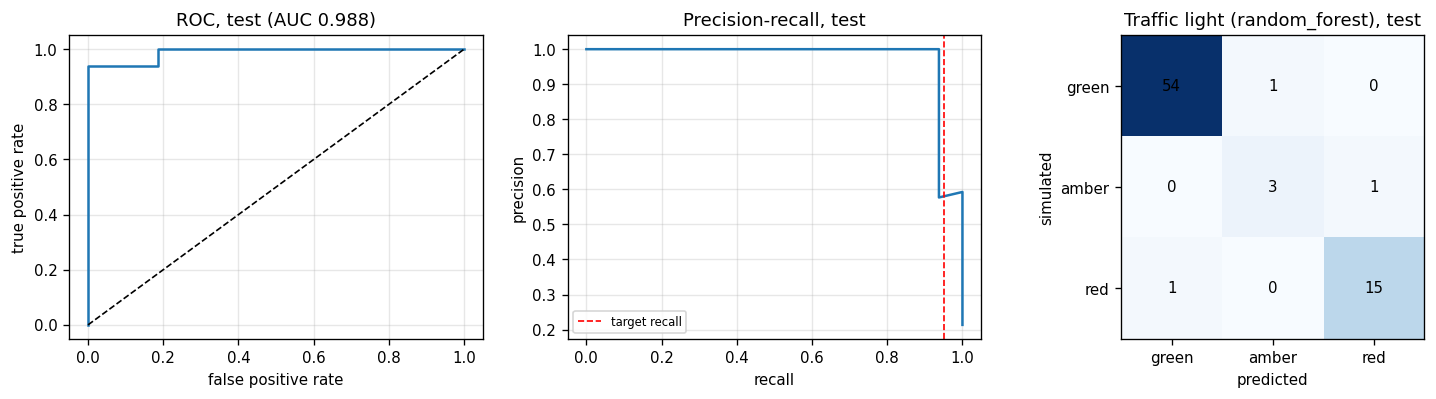

In [5]:
b = S['classifier']['binary']
display(pd.DataFrame(b['families']).T)
print('imbalance handling (logistic, out-of-fold, threshold 0.5):')
display(pd.DataFrame(b['imbalance_study_logistic_oof']).T)
for k in ('test_default_threshold', 'test_selected_threshold', 'test_regression_surrogate_thresholded'):
    print(k, {kk: v for kk, v in b[k].items()})
tl = S['classifier']['traffic_light']
display(pd.DataFrame(tl['families']).T); print('test:', tl['test'])
display(Image(str(Path(cfg.paths.figures)/'10_classifier.png')))

## Uncertainty: Monte Carlo over the assumed prior and error sources

In [6]:
for t, r in S['uncertainty']['targets'].items():
    print(t, {k: round(v, 4) for k, v in r['monte_carlo_prior'].items() if isinstance(v, float)})
    e = r['error_sources']; print('   shares input/surrogate/numerical %:',
          round(e['share_input_pct'], 1), round(e['share_surrogate_pct'], 1), round(e['share_numerical_pct'], 1))

dp_bh_max_MPa {'mean': 5.6742, 'std': 4.9819, 'P90_low_case': 0.9973, 'P50': 3.9263, 'P10_high_case': 14.2829}
   shares input/surrogate/numerical %: 96.6 2.6 0.9
r_plume_m95_m {'mean': 252.1515, 'std': 149.2239, 'P90_low_case': 105.4555, 'P50': 203.1647, 'P10_high_case': 464.7796}
   shares input/surrogate/numerical %: 98.2 0.3 1.5
sweep_efficiency {'mean': 0.0123, 'std': 0.0108, 'P90_low_case': 0.0017, 'P50': 0.009, 'P10_high_case': 0.0293}
   shares input/surrogate/numerical %: 92.4 2.8 4.8


## ML-method studies (training reservoirs only)


## scaler_comparison
{
 "knn": {
  "none": 0.7441116318747374,
  "standard": 0.455110538680495,
  "minmax": 0.4593258851630598,
  "robust": 0.43980693263374593
 },
 "svr": {
  "none": 0.6385487517920151,
  "standard": 0.33801910610365615,
  "minmax": 0.2944175119350397,
  "robust": 0.28479237394137097
 },
 "ridge": {
  "none": 0.15920406387488745,
  "standard": 0.10376802675545233,
  "minmax": 0.16758636400520394,
  "robust": 0.12333447849383777
 }
}

## missing_descriptors
{
 "permeability": {
  "columns": [
   "log10_k_mD",
   "log10_kh",
   "log10_injectivity",
   "log10_q_ref",
   "log10_q_mult_mean",
   "q_mult_max"
  ],
  "mean": 0.5037920496441272,
  "median": 0.513453068301991,
  "drop_feature": 0.1258578302434025,
  "complete": 0.10168669484793724
 },
 "Dykstra-Parsons": {
  "columns": [
   "V_DP",
   "V_DP_layers"
  ],
  "mean": 0.10209828810307357,
  "median": 0.1020990063942608,
  "drop_feature": 0.10214210344054517,
  "complete": 0.10168669484793724
 },
 "CO2 end-point kr

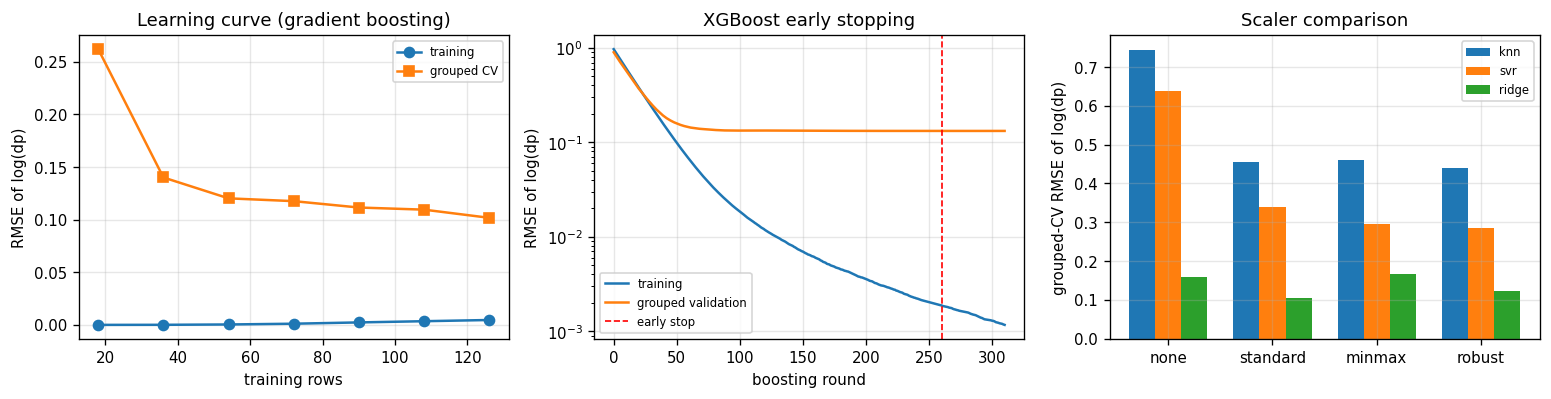

In [7]:
st = S['studies']
for k in ('scaler_comparison', 'missing_descriptors', 'outliers', 'polynomial', 'column_transformer',
          'split_comparison', 'ensembles', 'normal_equation'):
    v = st[k]; print('\n##', k)
    print(json.dumps({a: b for a, b in v.items() if a != 'gd_cost_history_every_500'}, indent=1, default=str)[:1500])
print(json.dumps({k: st['feature_selection'][k] for k in st['feature_selection']}, indent=1)[:2000])
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'best'} for k, v in st['tuning_strategies'].items()}, indent=1))
display(Image(str(Path(cfg.paths.figures)/'14_ml_studies.png')))

## Interpretation (model behaviour, not causality) and plume shapes

,feature,importance_mean,importance_std
0,log10_q_mult_mean,5.551245,0.280531
1,r_fill_over_re,0.176294,0.050590
2,q_front_load,0.036291,0.024566
3,q_ramp,0.004448,0.005275
4,n_g,0.003345,0.004085
5,n_a,0.001212,0.006790
6,h_total_m,0.000000,0.000000
7,krg0,0.000000,0.000000


,feature,mean_abs_shap
0,log10_q_mult_mean,0.566945
1,dimensionless_mass,0.160809
2,r_fill_over_re,0.088632
3,q_mult_max,0.021104
4,q_ramp,0.013651
5,q_front_load,0.008710
6,V_DP_layers,0.005283
7,n_g,0.004305


{
 "scenario_id": "R0072_S+02",
 "simulated_dp_MPa": 9.193439378803664,
 "predicted_dp_MPa": 9.459521241124309,
 "lime_top6": [
  {
   "feature": "log10_q_mult_mean",
   "local_effect_per_sd": 9.527029547722352
  },
  {
   "feature": "r_fill_over_re",
   "local_effect_per_sd": 0.6900321074533247
  },
  {
   "feature": "n_a",
   "local_effect_per_sd": 0.15396345105123743
  },
  {
   "feature": "q_front_load",
   "local_effect_per_sd": -0.15235720492049853
  },
  {
   "feature": "aspect_ratio",
   "local_effect_per_sd": -0.12696641907422584
  },
  {
   "feature": "h_total_m",
   "local_effect_per_sd": -0.11091590274646963
  }
 ],
 "what_if": {
  "largest_rate_factor_predicted_below_limit": 0.94,
  "limit_MPa": 9.0
 }
}
{
 "n_profiles": 300,
 "n_bins": 24,
 "explained_variance_ratio": [
  0.6864641447834721,
  0.13871876372665443,
  0.09293855630965506,
  0.0432480515370796,
  0.017440451418791976,
  0.006620718386151536,
  0.0050000892617295045,
  0.004337974569783238
 ],
 "n_components_

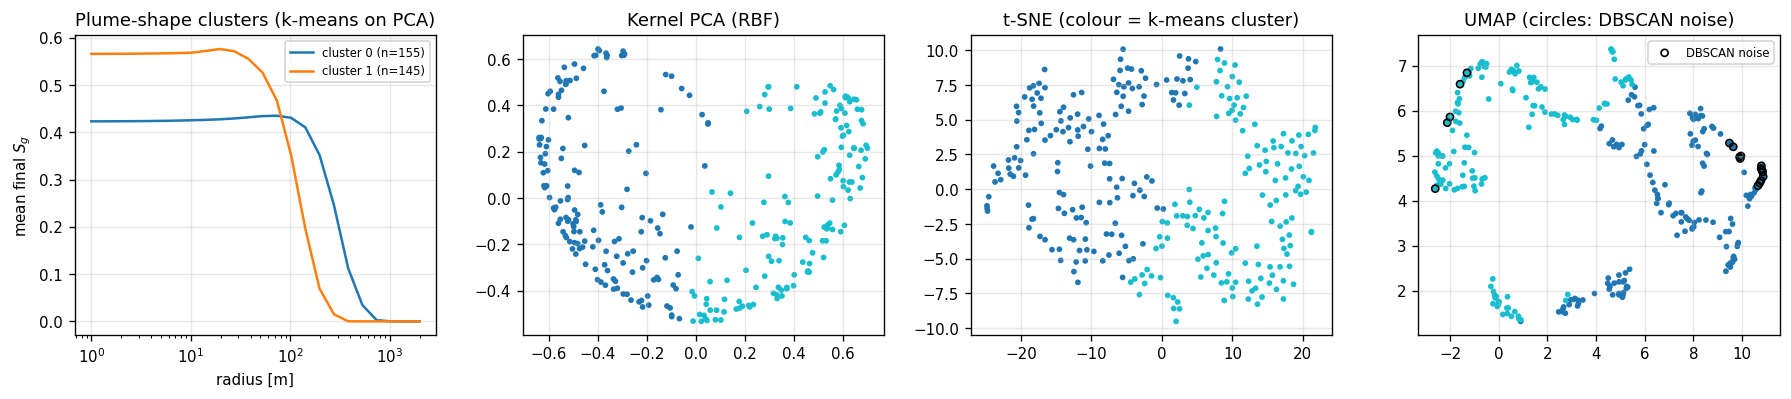

In [8]:
I = S['interpretation']
display(pd.DataFrame(I['dp_bh_max_MPa']['permutation_top8']))
if 'shap' in I: display(pd.DataFrame(I['shap']['top'][:8]))
print(json.dumps(I['local_case'], indent=1, default=str))
print(json.dumps(I.get('plume_shapes', {}), indent=1)[:1500])
display(Image(str(Path(cfg.paths.figures)/'13_plume_shapes.png')))

## Cost

In [9]:
print(json.dumps(S['speed'], indent=1))

{
 "hardware_note": "same machine, same process, 1 scenario at a time for the simulator; scikit-learn/XGBoost default threading",
 "n_test_rows_batch": 75,
 "surrogate_batch_seconds_total": 0.005829653999171569,
 "surrogate_seconds_per_case_batched": 7.772871998895425e-05,
 "surrogate_seconds_single_call_median": 0.005129482000484131,
 "surrogate_seconds_single_end_to_end_median": 0.017397188999893842,
 "simulator_seconds_per_case_mean_serial": 0.9018697701998463,
 "simulator_cases_timed": 5,
 "simulator_seconds_per_case_dataset_mean": 0.5927685803867159,
 "speedup_batched": 11602.786850574765,
 "speedup_single_call": 175.82082754452125,
 "speedup_single_end_to_end": 51.839970825479305,
 "outputs_compared": "the three scalar QoIs (dp_bh_max, r_plume_m95, sweep efficiency); the simulator also yields full fields and time series the surrogate does not",
 "dataset_generation_wall_seconds": 102.63547132299936,
 "dataset_generation_cpu_seconds": 199.56138583299435,
 "surrogate_training_secon